### Push Changes to GitHub

Use the following commands to configure Git, commit your changes, and push them to your GitHub repository. Replace `your_email@example.com`, `Your Name`, and the commit message with your actual details.

In [ ]:
# Configure your Git email and username (if not already set in this session)
!git config user.email "your_email@example.com"
!git config user.name "Your Name"

In [ ]:
# Stage all changes
!git add .

# Commit your changes
!git commit -m "Update: Improve test split logic and generate_caption fallback"

# Push to your remote repository (assuming 'origin' is your remote and 'feat/lstm' is your branch)
!git push origin feat/lstm

# LSTM Image Captioning

Training dan eksperimen model LSTM untuk image captioning.

---

In [ ]:
  import os

  IN_COLAB = 'google.colab' in str(get_ipython())

  if IN_COLAB:
      !git clone https://github.com/mahesa005/PixelToCaption.git
      %cd PixelToCaption
      !git checkout feat/lstm

      !pip install -q nltk tqdm pillow

      from google.colab import drive
      drive.mount('/content/drive')

      DRIVE_PROJECT_BASE_PATH = '/content/drive/MyDrive/Mahesa/Academic/S1 - Teknik Informatika/Semester 6/Machine Learning/Tubes 2/Training/'

      os.makedirs('data', exist_ok=True)
      !ln -sf "{DRIVE_PROJECT_BASE_PATH}captions.txt" "data/captions.txt"
      !ln -sf "{DRIVE_PROJECT_BASE_PATH}flickr8k_features.npy" "data/flickr8k_features.npy"
      !ln -sf "{DRIVE_PROJECT_BASE_PATH}tokenizer.json" "data/tokenizer.json"
      !ln -sf "{DRIVE_PROJECT_BASE_PATH}Images" "data/Images"

      DRIVE_WEIGHTS_SAVE_PATH = DRIVE_PROJECT_BASE_PATH + 'weights/lstm'
      os.makedirs(DRIVE_WEIGHTS_SAVE_PATH, exist_ok=True)
      os.makedirs('weights', exist_ok=True)
      !ln -sf "{DRIVE_WEIGHTS_SAVE_PATH}" "weights/lstm"


## 1. Setup & Imports

In [8]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Resolve project root: works when Jupyter is started from project root OR from src/lstm/
ROOT_DIR = Path('.').resolve()
if not (ROOT_DIR / 'src').exists():
    ROOT_DIR = (Path('..') / '..').resolve()
SRC_DIR = ROOT_DIR / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print(f'Project root : {ROOT_DIR}')
print(f'src on path  : {SRC_DIR}')

import tensorflow as tf
import keras
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Concatenate, Reshape
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
try:
    from tensorflow.keras.preprocessing.text import tokenizer_from_json
except ImportError:
    # Fallback for versions where tokenizer_from_json is not available
    from tensorflow.keras.preprocessing.text import Tokenizer
    def tokenizer_from_json(json_string):
        """Load tokenizer from JSON string (fallback implementation)"""
        import json as json_module
        config = json_module.loads(json_string)
        tokenizer = Tokenizer(**config.get('config', {}))
        tokenizer.word_index = config.get('word_index', {})
        tokenizer.word_counts = config.get('word_counts', {})
        tokenizer.word_docs = config.get('word_docs', {})
        tokenizer.document_count = config.get('document_count', 0)
        return tokenizer

print(f'Keras version: {keras.__version__}')


Project root : /content/PixelToCaption/PixelToCaption
src on path  : /content/PixelToCaption/PixelToCaption/src
Keras version: 3.13.2


In [ ]:
# Config
EMBED_DIM  = 256
HIDDEN_DIM = 512
EPOCHS     = 20
BATCH_SIZE = 64

# Paths
DATA_DIR       = ROOT_DIR / 'data'
CAPTIONS_PATH  = DATA_DIR / 'captions.txt'
FEATURES_PATH  = DATA_DIR / 'flickr8k_features.npy'
TOKENIZER_PATH = DATA_DIR / 'tokenizer.json'
IMAGES_DIR     = DATA_DIR / 'Images'
WEIGHTS_DIR    = ROOT_DIR / 'weights' / 'lstm'

print('Paths:')
for label, p in [
    ('captions',  CAPTIONS_PATH),
    ('features',  FEATURES_PATH),
    ('tokenizer', TOKENIZER_PATH),
    ('images',    IMAGES_DIR),
    ('weights',   WEIGHTS_DIR),
]:
    status = 'OK' if p.exists() else 'NOT FOUND'
    print(f'  {label:<12}: {p}  [{status}]')


In [10]:
print(f'Contents of DRIVE_PROJECT_BASE_PATH ({DRIVE_PROJECT_BASE_PATH}):')
!ls -l "{DRIVE_PROJECT_BASE_PATH}"

Contents of DRIVE_PROJECT_BASE_PATH (/content/drive/MyDrive/Mahesa/Academic/S1 - Teknik Informatika/Semester 6/Machine Learning/Tubes 2/Training/):
total 37400
-rw------- 1 root root  3359750 May 12 05:04 captions.txt
-rw------- 1 root root 33944841 May 14 08:13 flickr8k_features.npy
drwx------ 2 root root     4096 May 15 07:03 Images
drwx------ 2 root root     4096 May 14 17:34 LSTM
-rw------- 1 root root   979032 May 14 16:47 tokenizer.json
drwx------ 3 root root     4096 May 15 06:25 weights


Please examine the output above to ensure that `flickr8k_features.npy`, `tokenizer.json`, and an `Images` directory (containing images) exist directly within your `DRIVE_PROJECT_BASE_PATH`. Also, check for a `weights` directory inside `DRIVE_PROJECT_BASE_PATH`, which should contain `lstm`.

---
## 2. Feature Extraction

Ekstrak fitur CNN dari seluruh gambar Flickr8k menggunakan InceptionV3 dan simpan ke data/flickr8k_features.npy.
Jika file sudah ada, langkah ini akan dilewati.

In [11]:
from shared.image_utils import extract_features

if FEATURES_PATH.exists():
    print(f'Features already exist at {FEATURES_PATH}')
    features = np.load(str(FEATURES_PATH), allow_pickle=True).item()
else:
    assert IMAGES_DIR.exists(), f'Images directory not found: {IMAGES_DIR}'
    image_paths = sorted(IMAGES_DIR.glob('*.jpg'))
    assert len(image_paths) > 0, f'No .jpg images found in {IMAGES_DIR}'
    print(f'Found {len(image_paths)} images — starting extraction...')

    encoder = InceptionV3(weights='imagenet', include_top=False, pooling='avg')
    features = extract_features(
        paths=[str(p) for p in image_paths],
        output_path=str(FEATURES_PATH),
        batch_size=64,
        encoder=encoder,
    )

sample_key = next(iter(features))
print(f'Loaded {len(features)} features. Sample shape: {features[sample_key].shape}')


Features already exist at /content/PixelToCaption/PixelToCaption/data/flickr8k_features.npy
Loaded 4112 features. Sample shape: (2048,)


---
## 3. Caption Preprocessing

Load captions.txt, bersihkan, bangun tokenizer, dan hitung max_length.
Tokenizer disimpan ke data/tokenizer.json.

In [12]:
import csv as _csv

from shared.preprocessing import (
    load_captions,
    clean_and_wrap_captions,
    build_tokenizer,
    calculate_max_length,
)

assert CAPTIONS_PATH.exists(), f'captions.txt not found: {CAPTIONS_PATH}'

# ── Detect file format from first non-header line ─────────────────────────
with open(str(CAPTIONS_PATH), 'r', encoding='utf-8') as _f:
    _header = _f.readline()
    _sample = _f.readline()

_delim = '\t' if '\t' in _sample else ','
print(f'Detected delimiter: {"TAB" if _delim == chr(9) else "COMMA"}')

caption_mapping = load_captions(str(CAPTIONS_PATH))   # works when tab-delimited

# ── Fallback: re-parse with comma delimiter if tab parsing returned nothing ─
if len(caption_mapping) == 0:
    print('Tab-delimited parsing returned 0 captions — retrying with comma delimiter...')
    _mapping = {}
    with open(str(CAPTIONS_PATH), 'r', encoding='utf-8', newline='') as _f:
        _rows = _csv.reader(_f, delimiter=',')
        next(_rows, None)                              # skip header
        for _row in _rows:
            if len(_row) < 2:
                continue
            _img_id  = _row[0].strip()
            _caption = _row[1].strip()
            if _img_id and _caption:
                _mapping.setdefault(_img_id, []).append(_caption)
    caption_mapping = _mapping
    print(f'Comma-delimited fallback loaded {len(caption_mapping)} images.')

assert len(caption_mapping) > 0, (
    'caption_mapping is still empty after both tab and comma parsing.\n'
    f'Check that {CAPTIONS_PATH} has format: image_id<delim>caption'
)

print(f'Loaded captions for {len(caption_mapping)} images.')

cleaned_mapping = clean_and_wrap_captions(caption_mapping)
tokenizer, all_captions = build_tokenizer(cleaned_mapping, str(TOKENIZER_PATH))
max_length = calculate_max_length(all_captions)
vocab_size = len(tokenizer.word_index) + 1

print(f'vocab_size    : {vocab_size}')
print(f'max_length    : {max_length}')
print(f'total captions: {len(all_captions)}')


Detected delimiter: COMMA
Tab-delimited parsing returned 0 captions — retrying with comma delimiter...
Comma-delimited fallback loaded 8091 images.
Loaded captions for 8091 images.
Ukuran Vocabulary: 8832
Tokenizer berhasil disimpan di /content/PixelToCaption/PixelToCaption/data/tokenizer.json
Maximum Caption Length: 38
vocab_size    : 8832
max_length    : 38
total captions: 40455


---
## 4. Prepare Training Data

Buat pasangan input-output (cnn_feature, caption_prefix) menggunakan teacher forcing.

In [13]:
from lstm.train import prepare_sequences

print('Preparing training sequences...')
X, y = prepare_sequences(features, tokenizer, cleaned_mapping, max_length, EMBED_DIM)

cnn_features  = np.array([x[0] for x in X])   # (N, 2048)
cap_sequences = np.array([x[1] for x in X])   # (N, max_length)

print(f'Training samples    : {len(y)}')
print(f'cnn_features.shape  : {cnn_features.shape}')
print(f'cap_sequences.shape : {cap_sequences.shape}')


GPU enabled: ['/physical_device:GPU:0']
Preparing training sequences...
Training samples    : 243261
cnn_features.shape  : (243261, 2048)
cap_sequences.shape : (243261, 38)


---
## 5. Training Experiments

6 variasi kombinasi jumlah layer LSTM dan hidden dimension:

| Variasi | LSTM Layers | Hidden Dim |
|---------|-------------|------------|
| 1 | 1 | 128 |
| 2 | 2 | 128 |
| 3 | 3 | 128 |
| 4 | 1 | 512 |
| 5 | 2 | 512 |
| 6 | 3 | 512 |

In [14]:
def build_model_variant(
    vocab_size: int,
    embed_dim: int,
    max_length: int,
    hidden_dim: int,
    n_layers: int,
    cnn_feature_dim: int = 2048,
) -> Model:
    """Keras model dengan stacked LSTM layers yang dapat dikonfigurasi."""
    # CNN feature branch
    cnn_input = Input(shape=(cnn_feature_dim,), name='cnn_input')
    cnn_proj  = Dense(embed_dim, activation='relu', name='cnn_proj')(cnn_input)
    cnn_proj  = Reshape((1, embed_dim), name='cnn_reshape')(cnn_proj)

    # Caption sequence branch
    cap_input = Input(shape=(max_length,), name='cap_input')
    cap_embed = Embedding(vocab_size, embed_dim, mask_zero=True, name='embedding')(cap_input)

    # Pre-inject: prepend CNN feature vector ke awal sequence -> (max_length+1, embed_dim)
    merged = Concatenate(axis=1, name='pre_inject')([cnn_proj, cap_embed])

    # Stacked LSTM layers
    x = merged
    for i in range(n_layers):
        return_seq = (i < n_layers - 1)  # semua layer kecuali terakhir return sequences
        x = LSTM(hidden_dim, return_sequences=return_seq, name=f'lstm_{i + 1}')(x)

    outputs = Dense(vocab_size, activation='softmax', name='output')(x)

    model = Model(inputs=[cnn_input, cap_input], outputs=outputs)
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model



  Variation : 1layers_128hidden
  Weights   : /content/PixelToCaption/PixelToCaption/weights/lstm/lstm_1layers_128hidden.weights.h5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cnn_input           │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cap_input           │ (None, 38)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_proj (Dense)    │ (None, 256)       │    524,544 │ cnn_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 38, 256)   │  2,260,992 │ cap_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 38)        │          0 │ cap_input[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_reshape         │ (None, 1, 256)    │          0 │ cnn_proj[0][0]    │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims         │ (None, 38, 1)     │          0 │ not_equal[0][0]   │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zeros_like          │ (None, 38, 256)   │          0 │ embedding[0][0]   │
│ (ZerosLike)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ones_like           │ (None, 1, 256)    │          0 │ cnn_reshape[0][0] │
│ (OnesLike)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or          │ (None, 38, 256)   │          0 │ expand_dims[0][0… │
│ (LogicalOr)         │                   │            │ zeros_like[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 39, 256)   │          0 │ ones_like[0][0],  │
│ (Concatenate)       │                   │            │ logical_or[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pre_inject          │ (None, 39, 256)   │          0 │ cnn_reshape[0][0… │
│ (Concatenate)       │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 39)        │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 128)       │    197,120 │ pre_inject[0][0], │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 8832)      │  1,139,328 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,121,984 (15.72 MB)

 Trainable params: 4,121,984 (15.72 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 47s 12ms/step - accuracy: 0.2754 - loss: 4.2675 - val_accuracy: 0.3119 - val_loss: 3.9678
Epoch 2/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 74s 11ms/step - accuracy: 0.3446 - loss: 3.4475 - val_accuracy: 0.3439 - val_loss: 3.7208
Epoch 3/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - accuracy: 0.3715 - loss: 3.1312 - val_accuracy: 0.3497 - val_loss: 3.6652
Epoch 4/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - accuracy: 0.3908 - loss: 2.9207 - val_accuracy: 0.3578 - val_loss: 3.6420
Epoch 5/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 41s 11ms/step - accuracy: 0.4059 - loss: 2.7580 - val_accuracy: 0.3646 - val_loss: 3.6469
Epoch 6/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - accuracy: 0.4196 - loss: 2.6212 - val_accuracy: 0.3647 - val_loss: 3.6709
Epoch 7/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - accuracy: 0.4340 - loss: 2.4980 - val_accuracy: 0.3583 - val_loss: 3.7080
Epoch 8/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.4487 -

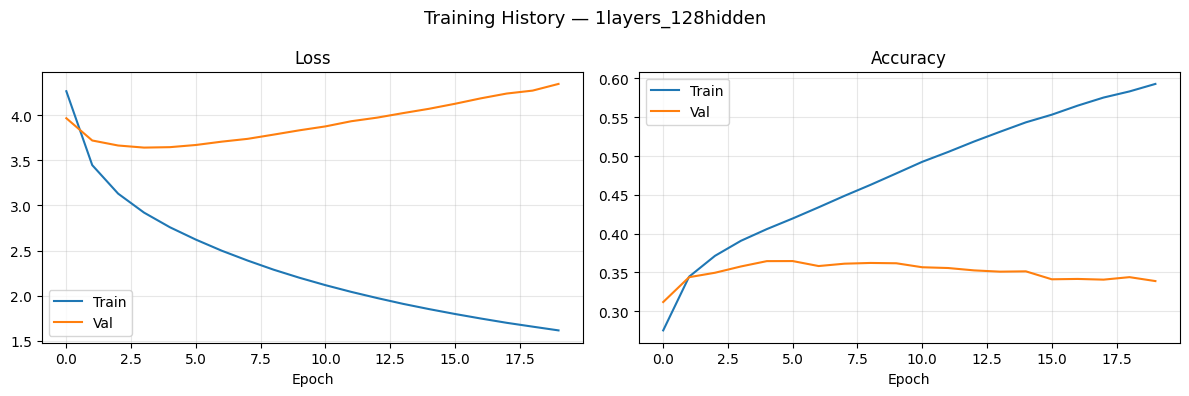


  Variation : 2layers_128hidden
  Weights   : /content/PixelToCaption/PixelToCaption/weights/lstm/lstm_2layers_128hidden.weights.h5


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cnn_input           │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cap_input           │ (None, 38)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_proj (Dense)    │ (None, 256)       │    524,544 │ cnn_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 38, 256)   │  2,260,992 │ cap_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 38)        │          0 │ cap_input[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_reshape         │ (None, 1, 256)    │          0 │ cnn_proj[0][0]    │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims_1       │ (None, 38, 1)     │          0 │ not_equal_1[0][0] │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zeros_like_1        │ (None, 38, 256)   │          0 │ embedding[0][0]   │
│ (ZerosLike)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ones_like_1         │ (None, 1, 256)    │          0 │ cnn_reshape[0][0] │
│ (OnesLike)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or_1        │ (None, 38, 256)   │          0 │ expand_dims_1[0]… │
│ (LogicalOr)         │                   │            │ zeros_like_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 39, 256)   │          0 │ ones_like_1[0][0… │
│ (Concatenate)       │                   │            │ logical_or_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pre_inject          │ (None, 39, 256)   │          0 │ cnn_reshape[0][0… │
│ (Concatenate)       │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_1 (Any)         │ (None, 39)        │          0 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 39, 128)   │    197,120 │ pre_inject[0][0], │
│                     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 128)       │    131,584 │ lstm_1[0][0],     │
│                     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 8832)      │  1,139,328 │ lstm_2[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,253,568 (16.23 MB)

 Trainable params: 4,253,568 (16.23 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 46s 13ms/step - accuracy: 0.2531 - loss: 4.4555 - val_accuracy: 0.3023 - val_loss: 4.0697
Epoch 2/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - accuracy: 0.3321 - loss: 3.5591 - val_accuracy: 0.3272 - val_loss: 3.8142
Epoch 3/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - accuracy: 0.3546 - loss: 3.2648 - val_accuracy: 0.3398 - val_loss: 3.7260
Epoch 4/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - accuracy: 0.3716 - loss: 3.0670 - val_accuracy: 0.3492 - val_loss: 3.6973
Epoch 5/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - accuracy: 0.3846 - loss: 2.9153 - val_accuracy: 0.3517 - val_loss: 3.6847
Epoch 6/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 84s 13ms/step - accuracy: 0.3962 - loss: 2.7840 - val_accuracy: 0.3573 - val_loss: 3.6892
Epoch 7/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - accuracy: 0.4077 - loss: 2.6662 - val_accuracy: 0.3604 - val_loss: 3.7062
Epoch 8/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - accuracy: 0.4205 -

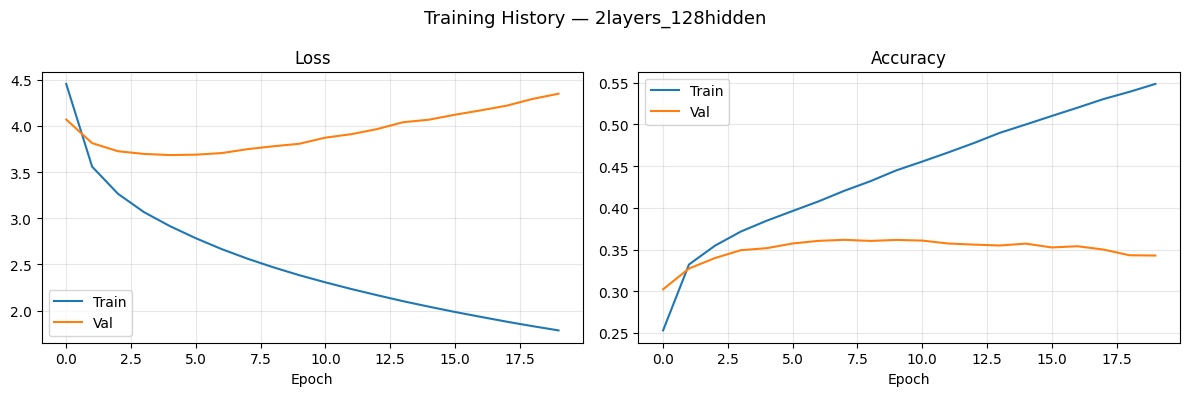


  Variation : 3layers_128hidden
  Weights   : /content/PixelToCaption/PixelToCaption/weights/lstm/lstm_3layers_128hidden.weights.h5


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cnn_input           │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cap_input           │ (None, 38)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_proj (Dense)    │ (None, 256)       │    524,544 │ cnn_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 38, 256)   │  2,260,992 │ cap_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 38)        │          0 │ cap_input[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_reshape         │ (None, 1, 256)    │          0 │ cnn_proj[0][0]    │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims_2       │ (None, 38, 1)     │          0 │ not_equal_2[0][0] │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zeros_like_2        │ (None, 38, 256)   │          0 │ embedding[0][0]   │
│ (ZerosLike)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ones_like_2         │ (None, 1, 256)    │          0 │ cnn_reshape[0][0] │
│ (OnesLike)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or_2        │ (None, 38, 256)   │          0 │ expand_dims_2[0]… │
│ (LogicalOr)         │                   │            │ zeros_like_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 39, 256)   │          0 │ ones_like_2[0][0… │
│ (Concatenate)       │                   │            │ logical_or_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pre_inject          │ (None, 39, 256)   │          0 │ cnn_reshape[0][0… │
│ (Concatenate)       │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_2 (Any)         │ (None, 39)        │          0 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 39, 128)   │    197,120 │ pre_inject[0][0], │
│                     │                   │            │ any_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 39, 128)   │    131,584 │ lstm_1[0][0],     │
│                     │                   │            │ any_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 128)       │    131,584 │ lstm_2[0][0],     │
│                     │                   │            │ any_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 8832)      │  1,139,328 │ lstm_3[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,385,152 (16.73 MB)

 Trainable params: 4,385,152 (16.73 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 57s 16ms/step - accuracy: 0.2381 - loss: 4.5929 - val_accuracy: 0.2868 - val_loss: 4.1818
Epoch 2/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 53s 15ms/step - accuracy: 0.3142 - loss: 3.6968 - val_accuracy: 0.3106 - val_loss: 3.9477
Epoch 3/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - accuracy: 0.3364 - loss: 3.4066 - val_accuracy: 0.3304 - val_loss: 3.8251
Epoch 4/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 52s 15ms/step - accuracy: 0.3539 - loss: 3.2013 - val_accuracy: 0.3356 - val_loss: 3.7906
Epoch 5/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 50s 15ms/step - accuracy: 0.3671 - loss: 3.0477 - val_accuracy: 0.3449 - val_loss: 3.7590
Epoch 6/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 84s 15ms/step - accuracy: 0.3784 - loss: 2.9230 - val_accuracy: 0.3478 - val_loss: 3.7535
Epoch 7/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 52s 15ms/step - accuracy: 0.3873 - loss: 2.8185 - val_accuracy: 0.3506 - val_loss: 3.7528
Epoch 8/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 52s 15ms/step - accuracy: 0.3969 -

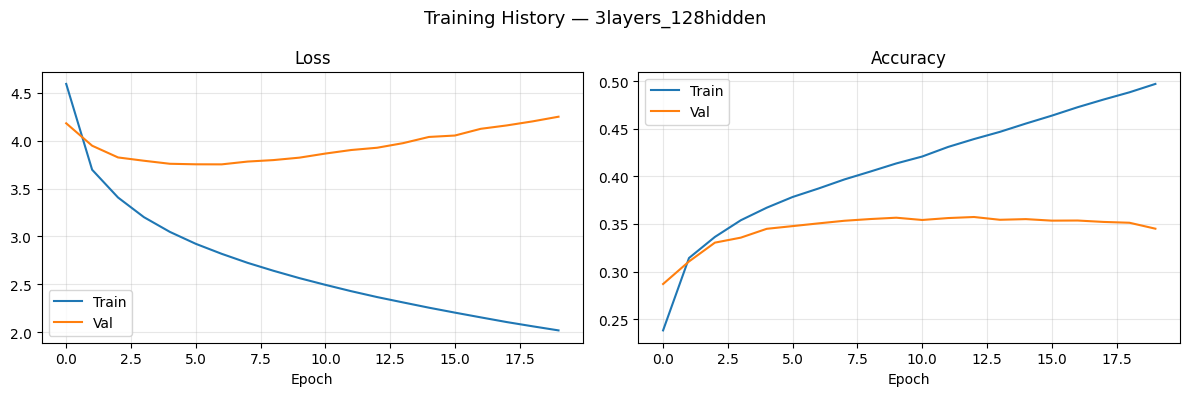


  Variation : 1layers_512hidden
  Weights   : /content/PixelToCaption/PixelToCaption/weights/lstm/lstm_1layers_512hidden.weights.h5


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cnn_input           │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cap_input           │ (None, 38)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_proj (Dense)    │ (None, 256)       │    524,544 │ cnn_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 38, 256)   │  2,260,992 │ cap_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_3         │ (None, 38)        │          0 │ cap_input[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_reshape         │ (None, 1, 256)    │          0 │ cnn_proj[0][0]    │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims_3       │ (None, 38, 1)     │          0 │ not_equal_3[0][0] │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zeros_like_3        │ (None, 38, 256)   │          0 │ embedding[0][0]   │
│ (ZerosLike)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ones_like_3         │ (None, 1, 256)    │          0 │ cnn_reshape[0][0] │
│ (OnesLike)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or_3        │ (None, 38, 256)   │          0 │ expand_dims_3[0]… │
│ (LogicalOr)         │                   │            │ zeros_like_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 39, 256)   │          0 │ ones_like_3[0][0… │
│ (Concatenate)       │                   │            │ logical_or_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pre_inject          │ (None, 39, 256)   │          0 │ cnn_reshape[0][0… │
│ (Concatenate)       │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_3 (Any)         │ (None, 39)        │          0 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 512)       │  1,574,912 │ pre_inject[0][0], │
│                     │                   │            │ any_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 8832)      │  4,530,816 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,891,264 (33.92 MB)

 Trainable params: 8,891,264 (33.92 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 56s 16ms/step - accuracy: 0.3061 - loss: 3.9441 - val_accuracy: 0.3349 - val_loss: 3.7503
Epoch 2/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 54s 16ms/step - accuracy: 0.3628 - loss: 3.2005 - val_accuracy: 0.3514 - val_loss: 3.6000
Epoch 3/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 55s 16ms/step - accuracy: 0.3960 - loss: 2.8125 - val_accuracy: 0.3628 - val_loss: 3.5664
Epoch 4/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 54s 16ms/step - accuracy: 0.4279 - loss: 2.4993 - val_accuracy: 0.3586 - val_loss: 3.6208
Epoch 5/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 82s 16ms/step - accuracy: 0.4653 - loss: 2.2230 - val_accuracy: 0.3586 - val_loss: 3.7050
Epoch 6/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 82s 16ms/step - accuracy: 0.5082 - loss: 1.9819 - val_accuracy: 0.3546 - val_loss: 3.8036
Epoch 7/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 54s 16ms/step - accuracy: 0.5496 - loss: 1.7748 - val_accuracy: 0.3495 - val_loss: 3.9151
Epoch 8/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 55s 16ms/step - accuracy: 0.5896 -

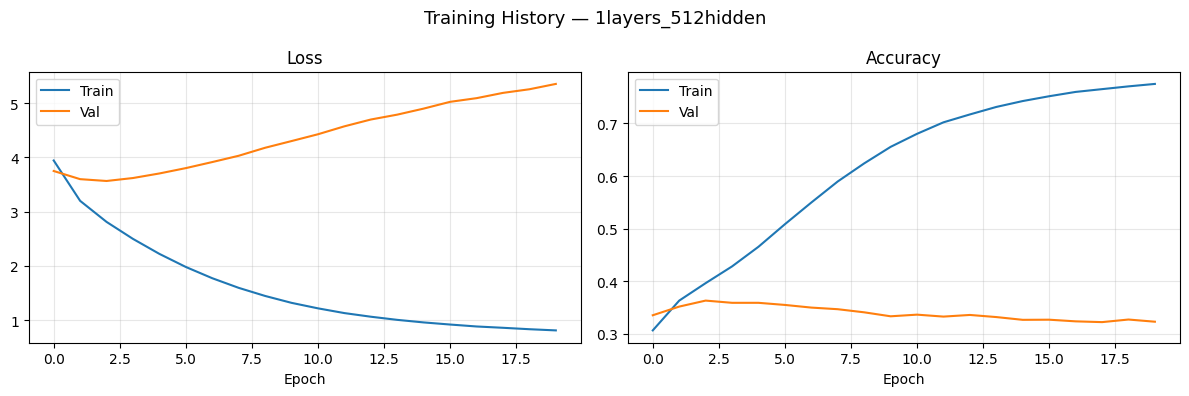


  Variation : 2layers_512hidden
  Weights   : /content/PixelToCaption/PixelToCaption/weights/lstm/lstm_2layers_512hidden.weights.h5


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cnn_input           │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cap_input           │ (None, 38)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_proj (Dense)    │ (None, 256)       │    524,544 │ cnn_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 38, 256)   │  2,260,992 │ cap_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_4         │ (None, 38)        │          0 │ cap_input[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_reshape         │ (None, 1, 256)    │          0 │ cnn_proj[0][0]    │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims_4       │ (None, 38, 1)     │          0 │ not_equal_4[0][0] │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zeros_like_4        │ (None, 38, 256)   │          0 │ embedding[0][0]   │
│ (ZerosLike)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ones_like_4         │ (None, 1, 256)    │          0 │ cnn_reshape[0][0] │
│ (OnesLike)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or_4        │ (None, 38, 256)   │          0 │ expand_dims_4[0]… │
│ (LogicalOr)         │                   │            │ zeros_like_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 39, 256)   │          0 │ ones_like_4[0][0… │
│ (Concatenate)       │                   │            │ logical_or_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pre_inject          │ (None, 39, 256)   │          0 │ cnn_reshape[0][0… │
│ (Concatenate)       │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_4 (Any)         │ (None, 39)        │          0 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 39, 512)   │  1,574,912 │ pre_inject[0][0], │
│                     │                   │            │ any_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 512)       │  2,099,200 │ lstm_1[0][0],     │
│                     │                   │            │ any_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 8832)      │  4,530,816 │ lstm_2[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,990,464 (41.93 MB)

 Trainable params: 10,990,464 (41.93 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 78s 22ms/step - accuracy: 0.2720 - loss: 4.2704 - val_accuracy: 0.3178 - val_loss: 3.8886
Epoch 2/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 73s 21ms/step - accuracy: 0.3505 - loss: 3.3448 - val_accuracy: 0.3435 - val_loss: 3.6768
Epoch 3/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 73s 21ms/step - accuracy: 0.3798 - loss: 2.9910 - val_accuracy: 0.3592 - val_loss: 3.5862
Epoch 4/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 73s 21ms/step - accuracy: 0.3992 - loss: 2.7322 - val_accuracy: 0.3654 - val_loss: 3.5854
Epoch 5/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 73s 21ms/step - accuracy: 0.4166 - loss: 2.5249 - val_accuracy: 0.3650 - val_loss: 3.6273
Epoch 6/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 73s 21ms/step - accuracy: 0.4361 - loss: 2.3483 - val_accuracy: 0.3668 - val_loss: 3.6972
Epoch 7/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 74s 22ms/step - accuracy: 0.4570 - loss: 2.1903 - val_accuracy: 0.3656 - val_loss: 3.7866
Epoch 8/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 74s 22ms/step - accuracy: 0.4802 -

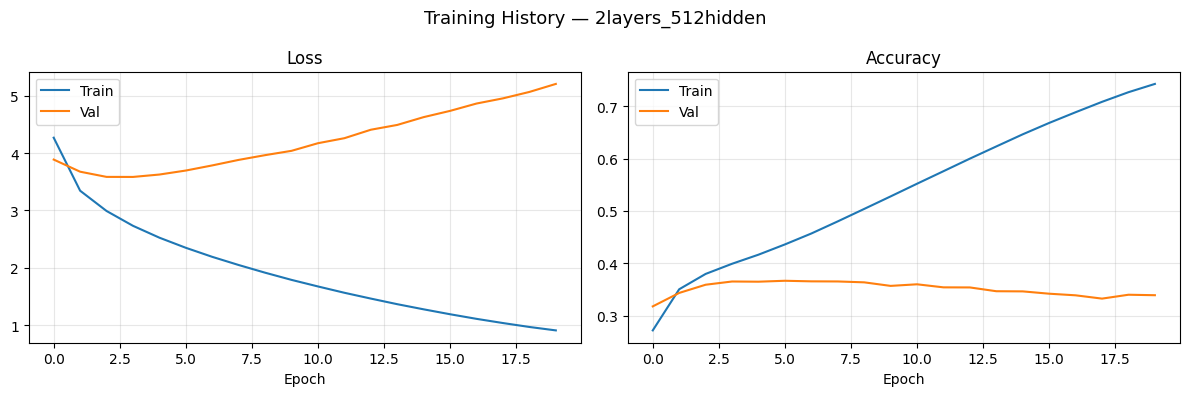


  Variation : 3layers_512hidden
  Weights   : /content/PixelToCaption/PixelToCaption/weights/lstm/lstm_3layers_512hidden.weights.h5


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cnn_input           │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cap_input           │ (None, 38)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_proj (Dense)    │ (None, 256)       │    524,544 │ cnn_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 38, 256)   │  2,260,992 │ cap_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_5         │ (None, 38)        │          0 │ cap_input[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_reshape         │ (None, 1, 256)    │          0 │ cnn_proj[0][0]    │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims_5       │ (None, 38, 1)     │          0 │ not_equal_5[0][0] │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zeros_like_5        │ (None, 38, 256)   │          0 │ embedding[0][0]   │
│ (ZerosLike)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ones_like_5         │ (None, 1, 256)    │          0 │ cnn_reshape[0][0] │
│ (OnesLike)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or_5        │ (None, 38, 256)   │          0 │ expand_dims_5[0]… │
│ (LogicalOr)         │                   │            │ zeros_like_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 39, 256)   │          0 │ ones_like_5[0][0… │
│ (Concatenate)       │                   │            │ logical_or_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pre_inject          │ (None, 39, 256)   │          0 │ cnn_reshape[0][0… │
│ (Concatenate)       │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_5 (Any)         │ (None, 39)        │          0 │ concatenate_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 39, 512)   │  1,574,912 │ pre_inject[0][0], │
│                     │                   │            │ any_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 39, 512)   │  2,099,200 │ lstm_1[0][0],     │
│                     │                   │            │ any_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 512)       │  2,099,200 │ lstm_2[0][0],     │
│                     │                   │            │ any_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 8832)      │  4,530,816 │ lstm_3[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,089,664 (49.93 MB)

 Trainable params: 13,089,664 (49.93 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 101s 29ms/step - accuracy: 0.2435 - loss: 4.5280 - val_accuracy: 0.2993 - val_loss: 4.1136
Epoch 2/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 97s 28ms/step - accuracy: 0.3281 - loss: 3.5679 - val_accuracy: 0.3234 - val_loss: 3.8308
Epoch 3/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 95s 28ms/step - accuracy: 0.3549 - loss: 3.2148 - val_accuracy: 0.3409 - val_loss: 3.7048
Epoch 4/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 97s 28ms/step - accuracy: 0.3770 - loss: 2.9569 - val_accuracy: 0.3524 - val_loss: 3.6430
Epoch 5/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 97s 28ms/step - accuracy: 0.3953 - loss: 2.7424 - val_accuracy: 0.3583 - val_loss: 3.6742
Epoch 6/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 142s 28ms/step - accuracy: 0.4118 - loss: 2.5635 - val_accuracy: 0.3631 - val_loss: 3.6966
Epoch 7/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 94s 27ms/step - accuracy: 0.4291 - loss: 2.4053 - val_accuracy: 0.3617 - val_loss: 3.7541
Epoch 8/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 95s 28ms/step - accuracy: 0.4487

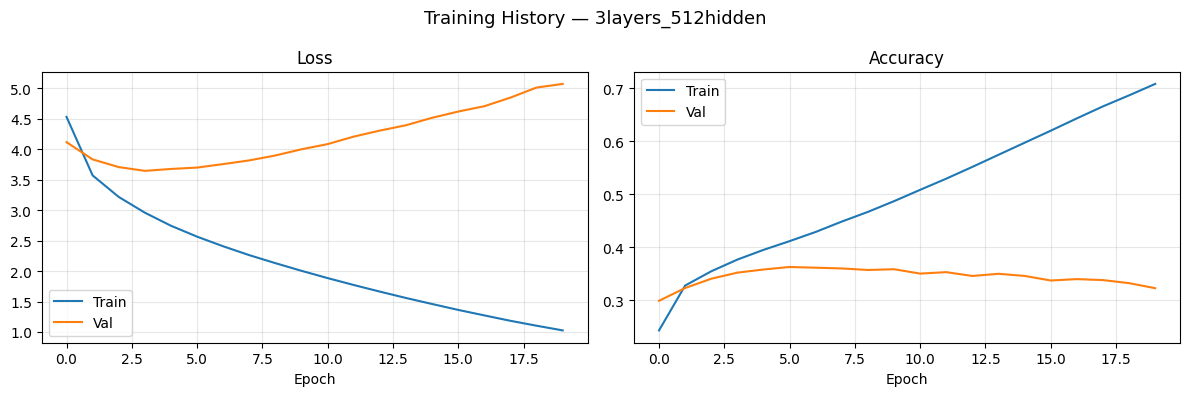


All variations trained.


In [15]:
VARIATIONS = [
    (1, 128),
    (2, 128),
    (3, 128),
    (1, 512),
    (2, 512),
    (3, 512),
]

all_histories = {}

for n_layers, hidden_dim in VARIATIONS:
    variant_name = f'{n_layers}layers_{hidden_dim}hidden'
    weights_path = WEIGHTS_DIR / f'lstm_{variant_name}.weights.h5'

    print('\n' + '=' * 60)
    print(f'  Variation : {variant_name}')
    print(f'  Weights   : {weights_path}')
    print('=' * 60)

    model = build_model_variant(vocab_size, EMBED_DIM, max_length, hidden_dim, n_layers)
    model.summary()

    history = model.fit(
        [cnn_features, cap_sequences],
        y,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        verbose=1,
    )

    model.save_weights(str(weights_path))
    print(f'Saved -> {weights_path}')
    all_histories[variant_name] = history.history

    # Per-variation loss/accuracy plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Training History — {variant_name}', fontsize=13)

    axes[0].plot(history.history['loss'],     label='Train')
    axes[0].plot(history.history['val_loss'], label='Val')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['accuracy'],     label='Train')
    axes[1].plot(history.history['val_accuracy'], label='Val')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(str(WEIGHTS_DIR / f'plot_{variant_name}.png'), dpi=100, bbox_inches='tight')
    plt.show()

print('\nAll variations trained.')


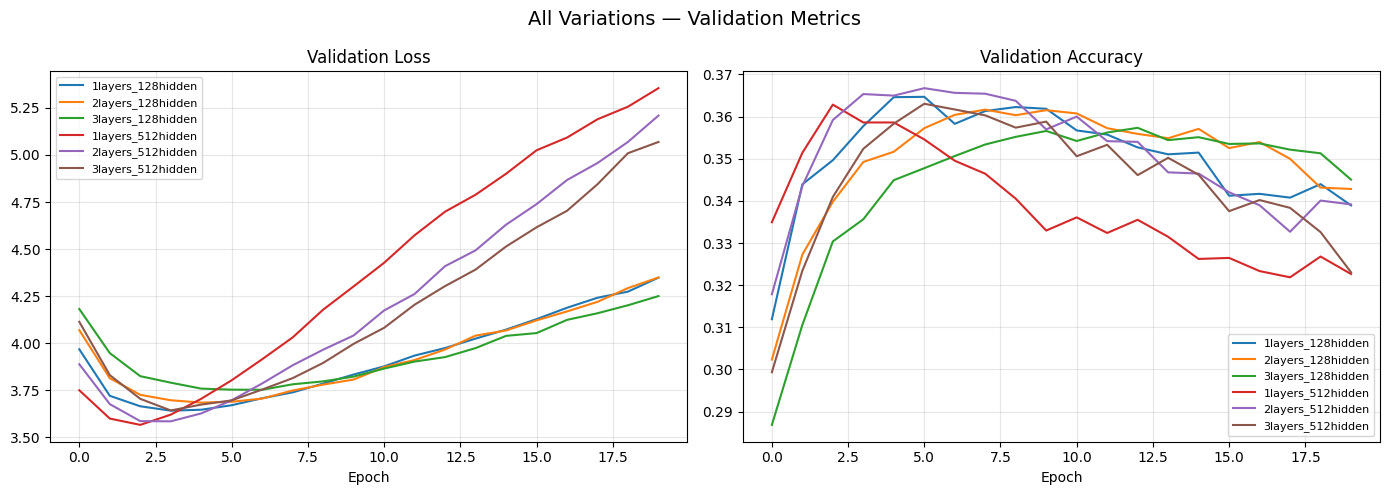


Variation                       Final Val Loss   Final Val Acc
--------------------------------------------------------------
1layers_128hidden                       4.3484          0.3389
2layers_128hidden                       4.3493          0.3428
3layers_128hidden                       4.2505          0.3450
1layers_512hidden                       5.3547          0.3226
2layers_512hidden                       5.2091          0.3392
3layers_512hidden                       5.0689          0.3231

Best variant (lowest val_loss): 3layers_128hidden


In [16]:
# Comparison: semua 6 variasi dalam satu plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('All Variations — Validation Metrics', fontsize=14)

for variant_name, hist in all_histories.items():
    axes[0].plot(hist['val_loss'],     label=variant_name)
    axes[1].plot(hist['val_accuracy'], label=variant_name)

for ax, title in zip(axes, ['Validation Loss', 'Validation Accuracy']):
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(WEIGHTS_DIR / 'comparison_all_variations.png'), dpi=100, bbox_inches='tight')
plt.show()

# Summary table
print(f'\n{"Variation":<30} {"Final Val Loss":>15} {"Final Val Acc":>15}')
print('-' * 62)
for variant_name, hist in all_histories.items():
    print(
        f'{variant_name:<30}'
        f' {hist["val_loss"][-1]:>15.4f}'
        f' {hist["val_accuracy"][-1]:>15.4f}'
    )

best_variant = min(all_histories, key=lambda k: all_histories[k]['val_loss'][-1])
print(f'\nBest variant (lowest val_loss): {best_variant}')


---
## 6. Evaluation

Load model terbaik berdasarkan val_loss terendah dan jalankan inference pada 5 sample gambar.

In [17]:
# Override manual jika perlu: best_variant = '1layers_512hidden'

best_n_layers, best_hidden = next(
    (n, h) for (n, h) in VARIATIONS
    if f'{n}layers_{h}hidden' == best_variant
)
print(f'Best variant : {best_variant}  (n_layers={best_n_layers}, hidden_dim={best_hidden})')

best_model = build_model_variant(vocab_size, EMBED_DIM, max_length, best_hidden, best_n_layers)
best_model.load_weights(str(WEIGHTS_DIR / f'lstm_{best_variant}.weights.h5'))
print('Model loaded.')


Best variant : 3layers_128hidden  (n_layers=3, hidden_dim=128)
Model loaded.


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
if 'tokenizer' not in dir():
    assert TOKENIZER_PATH.exists(), f'Tokenizer not found: {TOKENIZER_PATH}'
    with open(str(TOKENIZER_PATH), 'r', encoding='utf-8') as f:
        raw = f.read()
    parsed = json.loads(raw)
    if isinstance(parsed, str):
        raw = parsed
    tokenizer  = tokenizer_from_json(raw)
    vocab_size = len(tokenizer.word_index) + 1
    print(f'Tokenizer loaded. vocab_size={vocab_size}')

if 'features' not in dir():
    assert FEATURES_PATH.exists(), f'Features not found: {FEATURES_PATH}'
    features = np.load(str(FEATURES_PATH), allow_pickle=True).item()
    print(f'Features loaded. count={len(features)}')

if 'max_length' not in dir():
    raise RuntimeError('max_length not set — run Section 3 first or set manually, e.g. max_length = 34')

index_word = {v: k for k, v in tokenizer.word_index.items()}


In [ ]:
def generate_caption(
    model: Model,
    feature: np.ndarray,
    tokenizer,
    max_length: int,
    index_word: dict,
) -> str:
    """Greedy decoding: predict next word satu per satu hingga <end> atau max_length."""
    in_text = '<start>'
    for _ in range(max_length):
        seq       = tokenizer.texts_to_sequences([in_text])[0]
        seq       = pad_sequences([seq], maxlen=max_length, padding='post')
        pred      = model.predict([feature.reshape(1, -1), seq], verbose=0)
        next_idx  = int(np.argmax(pred[0]))
        next_word = index_word.get(next_idx, '<unk>')

        if next_word == '<end>':
            break
        in_text += ' ' + next_word

    final_caption = in_text.replace('<start>', '').strip()
    return final_caption if final_caption else '<unk>'


1000268201_693b08cb0e.jpg: a young boy is sitting on a wooden bench with a bird in his mouth
1001773457_577c3a7d70.jpg: a dog is running through the snow
1002674143_1b742ab4b8.jpg: a little girl in a pink shirt is running through the sand
1003163366_44323f5815.jpg: a woman in a black shirt and brown shorts is sitting on a bench
1007129816_e794419615.jpg: a man in a black jacket is standing in front of a brick wall


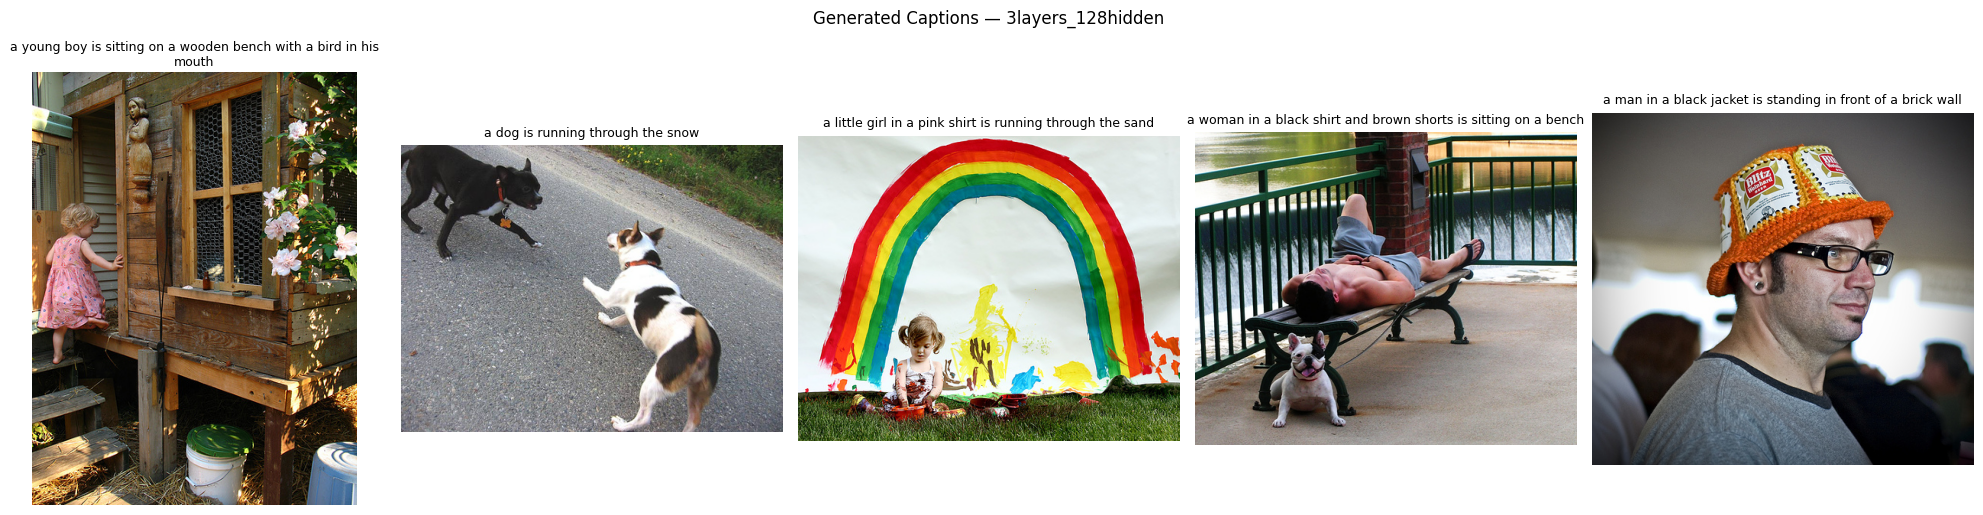

In [27]:
from PIL import Image
from shared.image_utils import load_image

assert IMAGES_DIR.exists(), f'Images directory not found: {IMAGES_DIR}'
sample_paths = sorted(IMAGES_DIR.glob('*.jpg'))[:5]
assert len(sample_paths) > 0, f'No images found in {IMAGES_DIR}'

_encoder = None  # lazy-loaded jika feature belum di-extract

fig, axes = plt.subplots(1, len(sample_paths), figsize=(4 * len(sample_paths), 5))
if len(sample_paths) == 1:
    axes = [axes]

for ax, img_path in zip(axes, sample_paths):
    img_name = img_path.name

    if img_name in features:
        feature = features[img_name]
    else:
        if _encoder is None:
            print('Building InceptionV3 for on-the-fly extraction...')
            _encoder = InceptionV3(weights='imagenet', include_top=False, pooling='avg')
        img_arr = load_image(str(img_path))
        feature = _encoder.predict(img_arr[np.newaxis, ...], verbose=0)[0]

    caption = generate_caption(best_model, feature, tokenizer, max_length, index_word)

    ax.imshow(Image.open(img_path).convert('RGB'))
    ax.set_title(caption, fontsize=9, wrap=True)
    ax.axis('off')
    print(f'{img_name}: {caption}')

plt.suptitle(f'Generated Captions — {best_variant}', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(str(WEIGHTS_DIR / 'sample_captions.png'), dpi=100, bbox_inches='tight')
plt.show()


---
## 7. BLEU-4 and METEOR Score per Variation

Evaluasi setiap variasi pada test split (last 1000 images).
Metrics: BLEU-4 (corpus), METEOR (average), waktu inferensi.

In [ ]:
import time
import nltk
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.translate.bleu_score  import corpus_bleu, sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score as _meteor_score

smoothie = SmoothingFunction().method4

common_image_ids = sorted(list(set(cleaned_mapping.keys()) & set(features.keys())))
test_image_ids   = common_image_ids[-1000:]
print(f'Test split size: {len(test_image_ids)} images')


def evaluate_on_test(caption_fn, test_ids, cleaned_mapping, smoothie):
    """
    caption_fn : callable(img_id) -> caption string
    Returns    : (bleu4, meteor, refs_corpus, hyps_corpus)
    """
    refs_corpus   = []
    hyps_corpus   = []
    meteor_scores = []

    for img_id in test_ids:
        hyp = caption_fn(img_id)
        refs_clean = [
            c.replace('<start>', '').replace('<end>', '').strip()
            for c in cleaned_mapping[img_id]
        ]
        hyp_tokens = hyp.split()
        ref_tokens = [r.split() for r in refs_clean]

        refs_corpus.append(ref_tokens)
        hyps_corpus.append(hyp_tokens)
        meteor_scores.append(_meteor_score(ref_tokens, hyp_tokens))

    if not refs_corpus:
        return 0.0, 0.0, [], []

    bleu4  = corpus_bleu(refs_corpus, hyps_corpus,
                         weights=(0.25, 0.25, 0.25, 0.25),
                         smoothing_function=smoothie)
    meteor = sum(meteor_scores) / len(meteor_scores) if meteor_scores else 0.0
    return bleu4, meteor, refs_corpus, hyps_corpus


In [29]:
scores_per_variation = {}

for n_layers, hidden_dim in VARIATIONS:
    variant_name = f'{n_layers}layers_{hidden_dim}hidden'
    weights_path = WEIGHTS_DIR / f'lstm_{variant_name}.weights.h5'

    if not weights_path.exists():
        print(f'[SKIP] {variant_name} — weights not found at {weights_path}')
        continue

    print(f'Evaluating {variant_name} ...', end=' ', flush=True)
    model = build_model_variant(vocab_size, EMBED_DIM, max_length, hidden_dim, n_layers)
    model.load_weights(str(weights_path))

    t0 = time.time()
    bleu4, meteor, _, _ = evaluate_on_test(
        lambda img_id, m=model: generate_caption(m, features[img_id], tokenizer, max_length, index_word),
        test_image_ids,
        cleaned_mapping,
        smoothie,
    )
    elapsed = time.time() - t0

    scores_per_variation[variant_name] = {
        'bleu4': bleu4, 'meteor': meteor, 'time': elapsed,
        'n_layers': n_layers, 'hidden_dim': hidden_dim,
    }
    print(f'BLEU-4={bleu4:.4f}  METEOR={meteor:.4f}  Time={elapsed:.1f}s')


Evaluating 1layers_128hidden ... 

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


BLEU-4=0.1393  METEOR=0.3470  Time=1051.0s
Evaluating 2layers_128hidden ... 

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 24 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


BLEU-4=0.1543  METEOR=0.3682  Time=1158.5s
Evaluating 3layers_128hidden ... 

...

BLEU-4=0.1483  METEOR=0.3427  Time=1069.1s
Evaluating 1layers_512hidden ... 

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


BLEU-4=0.1463  METEOR=0.3500  Time=1172.0s
Evaluating 2layers_512hidden ... 

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 24 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


BLEU-4=0.2298  METEOR=0.4254  Time=1091.6s
Evaluating 3layers_512hidden ... BLEU-4=0.2115  METEOR=0.4089  Time=1090.6s
